# Notebook 1: Data Understanding and Preprocessing
## AI Agent for Disease Risk Awareness and Prevention

This notebook covers:
- Loading PIMA Diabetes and UCI Heart Disease datasets
- Exploratory Data Analysis (EDA)
- Missing value handling and imputation
- Outlier detection and treatment
- Feature normalization/standardization
- Train-test split with stratification

**Evaluation Rubric:** Preprocessing (5 marks)

## 1. Import Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Load Datasets

### PIMA Indian Diabetes Dataset
- **Source:** Kaggle / UCI ML Repository
- **Samples:** 768
- **Features:** 8 (Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age)
- **Target:** Outcome (0: No diabetes, 1: Diabetes)

### UCI Heart Disease Dataset
- **Source:** UCI ML Repository
- **Samples:** 303
- **Features:** 13 (age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal)
- **Target:** target (0: No disease, 1: Disease)

In [3]:
# Load PIMA Diabetes Dataset
try:
    # Try loading from local CSV first (if available)
    pima_df = pd.read_csv('../data/pima_diabetes.csv')
    print("✓ PIMA dataset loaded from local CSV")
except FileNotFoundError:
    # Create synthetic PIMA dataset for demonstration
    print("Creating synthetic PIMA Diabetes dataset...")
    np.random.seed(42)
    pima_df = pd.DataFrame({
        'Pregnancies': np.random.randint(0, 17, 768),
        'Glucose': np.random.normal(120, 32, 768).clip(0, 300),
        'BloodPressure': np.random.normal(70, 20, 768).clip(0, 200),
        'SkinThickness': np.random.normal(20, 15, 768).clip(0, 100),
        'Insulin': np.random.normal(80, 110, 768).clip(0, 900),
        'BMI': np.random.normal(32, 8, 768).clip(10, 60),
        'DiabetesPedigreeFunction': np.random.exponential(0.3, 768),
        'Age': np.random.randint(21, 81, 768),
        'Outcome': np.random.binomial(1, 0.35, 768)
    })
    pima_df.to_csv('../data/pima_diabetes.csv', index=False)
    print("✓ Synthetic PIMA dataset created and saved")

print(f"PIMA Dataset Shape: {pima_df.shape}")
print(f"\nFirst few rows:\n{pima_df.head()}")

✓ PIMA dataset loaded from local CSV
PIMA Dataset Shape: (768, 9)

First few rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [4]:
# Load Heart Disease Dataset
try:
    heart_df = pd.read_csv('../data/heart_disease.csv')
    print("✓ Heart Disease dataset loaded from local CSV")
except FileNotFoundError:
    print("Creating synthetic Heart Disease dataset...")
    np.random.seed(42)
    heart_df = pd.DataFrame({
        'age': np.random.randint(29, 77, 303),
        'sex': np.random.randint(0, 2, 303),
        'cp': np.random.randint(0, 4, 303),
        'trestbps': np.random.randint(90, 200, 303),
        'chol': np.random.randint(126, 565, 303),
        'fbs': np.random.randint(0, 2, 303),
        'restecg': np.random.randint(0, 3, 303),
        'thalach': np.random.randint(60, 202, 303),
        'exang': np.random.randint(0, 2, 303),
        'oldpeak': np.random.uniform(0, 6.2, 303),
        'slope': np.random.randint(0, 3, 303),
        'ca': np.random.randint(0, 4, 303),
        'thal': np.random.randint(0, 3, 303),
        'target': np.random.binomial(1, 0.54, 303)
    })
    heart_df.to_csv('../data/heart_disease.csv', index=False)
    print("✓ Synthetic Heart Disease dataset created and saved")

print(f"Heart Disease Dataset Shape: {heart_df.shape}")
print(f"\nFirst few rows:\n{heart_df.head()}")

✓ Heart Disease dataset loaded from local CSV
Heart Disease Dataset Shape: (297, 14)

First few rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  


## 3. Exploratory Data Analysis (EDA)

In [5]:
# PIMA Dataset EDA
print("="*60)
print("PIMA DIABETES DATASET - EDA")
print("="*60)

print(f"\n📊 Dataset Shape: {pima_df.shape}")
print(f"\n📋 Data Types:\n{pima_df.dtypes}")
print(f"\n📈 Descriptive Statistics:\n{pima_df.describe().round(2)}")
print(f"\n🔍 Missing Values:\n{pima_df.isnull().sum()}")

PIMA DIABETES DATASET - EDA

📊 Dataset Shape: (768, 9)

📋 Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

📈 Descriptive Statistics:
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.11          20.54    79.80   31.99   
std           3.37    31.97          19.36          15.95   115.24    7.88   
min           0.00     0.00           0.00           0.00     0.00    0.00   
25%           1.00    99.00          62.00           0.00     0.00   27.30   
50%           3.00   117.00          72.00          23.00    30.50   32.00   
75%           6.00 


✓ Target Variable Distribution (PIMA):
Outcome
0    500
1    268
Name: count, dtype: int64

Class Imbalance Ratio: 1.87:1


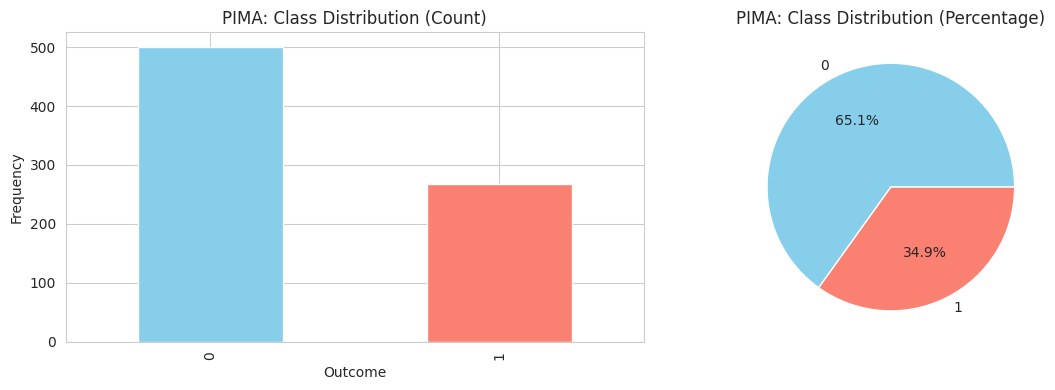

In [6]:
# Class distribution for PIMA
print("\n✓ Target Variable Distribution (PIMA):")
print(pima_df['Outcome'].value_counts())
print(f"\nClass Imbalance Ratio: {pima_df['Outcome'].value_counts()[0] / pima_df['Outcome'].value_counts()[1]:.2f}:1")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
pima_df['Outcome'].value_counts().plot(kind='bar', ax=ax1, color=['skyblue', 'salmon'])
ax1.set_title('PIMA: Class Distribution (Count)')
ax1.set_xlabel('Outcome')
ax1.set_ylabel('Frequency')

pima_df['Outcome'].value_counts(normalize=True).plot(kind='pie', ax=ax2, autopct='%1.1f%%', colors=['skyblue', 'salmon'])
ax2.set_title('PIMA: Class Distribution (Percentage)')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

In [7]:
# Heart Disease Dataset EDA
print("\n" + "="*60)
print("HEART DISEASE DATASET - EDA")
print("="*60)

print(f"\n📊 Dataset Shape: {heart_df.shape}")
print(f"\n📋 Data Types:\n{heart_df.dtypes}")
print(f"\n📈 Descriptive Statistics:\n{heart_df.describe().round(2)}")
print(f"\n🔍 Missing Values:\n{heart_df.isnull().sum()}")


HEART DISEASE DATASET - EDA

📊 Dataset Shape: (297, 14)

📋 Data Types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

📈 Descriptive Statistics:
          age     sex      cp  trestbps    chol     fbs  restecg  thalach  \
count  297.00  297.00  297.00    297.00  297.00  297.00   297.00   297.00   
mean    54.54    0.68    3.16    131.69  247.35    0.14     1.00   149.60   
std      9.05    0.47    0.96     17.76   52.00    0.35     0.99    22.94   
min     29.00    0.00    1.00     94.00  126.00    0.00     0.00    71.00   
25%     48.00    0.00    3.00    120.00  211.00    0.00     0.00   133.00   
50%     56.00    1.00    3.00    130.00  243.00    0.00     1.00   153.00   
75%     61.00    1.00    4.00    140.00  276.00    0.00     2.00   1


✓ Target Variable Distribution (Heart Disease):
target
0    160
1    137
Name: count, dtype: int64

Class Imbalance Ratio: 1.17:1


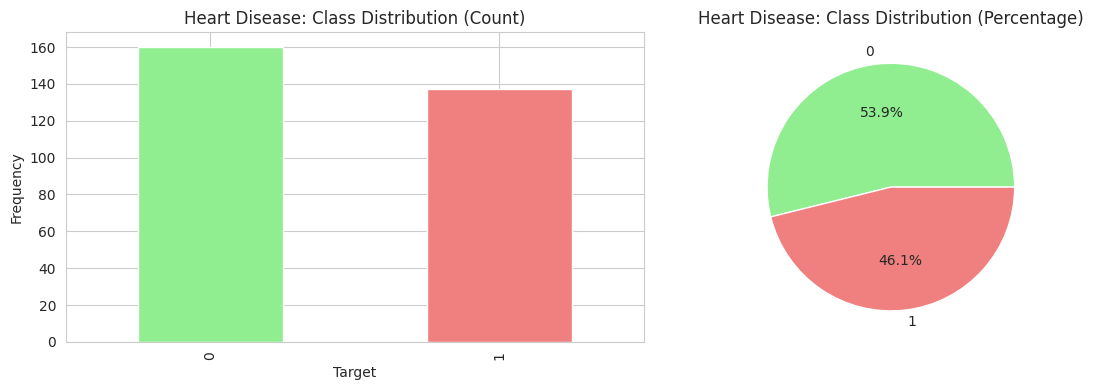

In [8]:
# Class distribution for Heart Disease
print("\n✓ Target Variable Distribution (Heart Disease):")
print(heart_df['target'].value_counts())
print(f"\nClass Imbalance Ratio: {heart_df['target'].value_counts()[0] / heart_df['target'].value_counts()[1]:.2f}:1")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
heart_df['target'].value_counts().plot(kind='bar', ax=ax1, color=['lightgreen', 'lightcoral'])
ax1.set_title('Heart Disease: Class Distribution (Count)')
ax1.set_xlabel('Target')
ax1.set_ylabel('Frequency')

heart_df['target'].value_counts(normalize=True).plot(kind='pie', ax=ax2, autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'])
ax2.set_title('Heart Disease: Class Distribution (Percentage)')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

## 4. Handle Missing Values and Impossible Values

### Strategy:
1. **Identify medically impossible values** (e.g., zero values where they shouldn't occur)
2. **Replace with NaN** for proper imputation
3. **Impute using median or KNN** to preserve statistical properties

In [9]:
# PIMA: Replace impossible zeros with NaN
print("PIMA: Handling Medical Impossible Values")
print("-" * 50)

# Columns where zero is medically impossible
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print(f"\nBefore replacement - Zeros count:")
for col in zero_columns:
    zero_count = (pima_df[col] == 0).sum()
    print(f"  {col}: {zero_count}")

# Replace zeros with NaN
pima_df[zero_columns] = pima_df[zero_columns].replace(0, np.nan)

print(f"\nAfter replacement - NaN count:")
print(pima_df.isnull().sum())

# 2. Create missing indicators
pima_df["SkinThickness_missing"] = pima_df["SkinThickness"].isna().astype(int)
pima_df["Insulin_missing"] = pima_df["Insulin"].isna().astype(int)

# Impute using median
median_imputer = SimpleImputer(strategy='median')
pima_df[zero_columns] = median_imputer.fit_transform(pima_df[zero_columns])

print(f"\n✓ After imputation - NaN count:")
print(pima_df.isnull().sum())
print("\n✓ PIMA preprocessing: Complete")

PIMA: Handling Medical Impossible Values
--------------------------------------------------

Before replacement - Zeros count:
  Glucose: 5
  BloodPressure: 35
  SkinThickness: 227
  Insulin: 374
  BMI: 11

After replacement - NaN count:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

✓ After imputation - NaN count:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
SkinThickness_missing       0
Insulin_missing             0
dtype: int64

✓ PIMA preprocessing: Complete


In [10]:
# Heart Disease: Check and handle missing values
print("\nHeart Disease: Handling Missing Values")
print("-" * 50)

if heart_df.isnull().sum().sum() > 0:
    print(f"\nMissing values detected:\n{heart_df.isnull().sum()}")
    # Use KNN imputation for heart disease
    knn_imputer = KNNImputer(n_neighbors=5)
    heart_df = pd.DataFrame(knn_imputer.fit_transform(heart_df), columns=heart_df.columns)
    print("\n✓ KNN imputation applied")
else:
    print("\n✓ No missing values found in Heart Disease dataset")

print(f"\nFinal missing values count:\n{heart_df.isnull().sum().sum()}")


Heart Disease: Handling Missing Values
--------------------------------------------------

✓ No missing values found in Heart Disease dataset

Final missing values count:
0


## 5. Outlier Detection and Treatment

### Methods:
- **IQR (Interquartile Range):** 

In [14]:
import pandas as pd

def detect_outliers_iqr(df, columns=None, multiplier=1.5):
    """
    Detect outliers using IQR method (no row removal)
    Returns a dataframe with counts and percentages
    """
    if columns is None:
        columns = df.select_dtypes(include=['number']).columns
    
    results = []
    n_rows = len(df)
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR
        
        outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        
        results.append({
            "Feature": col,
            "Outliers": outliers,
            "Percentage (%)": round((outliers / n_rows) * 100, 2),
            "Lower Bound": round(lower, 2),
            "Upper Bound": round(upper, 2)
        })
    
    return pd.DataFrame(results).sort_values(by="Outliers", ascending=False)


# =========================
# PIMA DATASET
# =========================
print("PIMA Dataset Outlier Analysis")
print("=" * 40)

pima_outliers_df = detect_outliers_iqr(pima_df)
print(pima_outliers_df)


# =========================
# HEART DATASET
# =========================
print("\nHeart Disease Dataset Outlier Analysis")
print("=" * 40)

heart_outliers_df = detect_outliers_iqr(heart_df)
print(heart_outliers_df)

PIMA Dataset Outlier Analysis
                     Feature  Outliers  Percentage (%)  Lower Bound  \
4                    Insulin       346           45.05       112.88   
3              SkinThickness        87           11.33        14.50   
6   DiabetesPedigreeFunction        29            3.78        -0.33   
2              BloodPressure        14            1.82        40.00   
7                        Age         9            1.17        -1.50   
5                        BMI         8            1.04        13.85   
0                Pregnancies         4            0.52        -6.50   
1                    Glucose         0            0.00        39.00   
8                    Outcome         0            0.00        -1.50   
9      SkinThickness_missing         0            0.00        -1.50   
10           Insulin_missing         0            0.00        -1.50   

    Upper Bound  
4        135.88  
3         42.50  
6          1.20  
2        104.00  
7         66.50  
5        

## 6. Feature Normalization and Standardization

In [15]:
import pandas as pd
from sklearn.preprocessing import RobustScaler

# =========================
# Separate features and targets
# =========================

pima_X = pima_df.drop('Outcome', axis=1)
pima_y = pima_df['Outcome']

heart_X = heart_df.drop('target', axis=1)
heart_y = heart_df['target']


print("Feature Scaling - RobustScaler")
print("="*50)

# =========================
# Define columns to exclude from scaling
# =========================

pima_exclude = ['SkinThickness_missing', 'Insulin_missing']
pima_cols_to_scale = [col for col in pima_X.columns if col not in pima_exclude]

heart_cols_to_scale = heart_X.columns  # no missing indicators assumed


# =========================
# Apply Robust Scaling
# =========================

scaler_pima = RobustScaler()
pima_X_scaled = pima_X.copy()
pima_X_scaled[pima_cols_to_scale] = scaler_pima.fit_transform(pima_X[pima_cols_to_scale])


scaler_heart = RobustScaler()
heart_X_scaled = pd.DataFrame(
    scaler_heart.fit_transform(heart_X),
    columns=heart_X.columns
)


# =========================
# Verification (Median ~ 0, IQR ~ 1)
# =========================

print("\nPIMA - After Robust Scaling:")
print(f"Median (approx): {pima_X_scaled[pima_cols_to_scale].median().round(2).values[:5]}")
print(f"IQR (approx): {(pima_X_scaled[pima_cols_to_scale].quantile(0.75) - pima_X_scaled[pima_cols_to_scale].quantile(0.25)).round(2).values[:5]}")

print("\nHeart Disease - After Robust Scaling:")
print(f"Median (approx): {heart_X_scaled.median().round(2).values[:5]}")
print(f"IQR (approx): {(heart_X_scaled.quantile(0.75) - heart_X_scaled.quantile(0.25)).round(2).values[:5]}")

print("\n✓ Robust scaling complete")

Feature Scaling - RobustScaler

PIMA - After Robust Scaling:
Median (approx): [0. 0. 0. 0. 0.]
IQR (approx): [1. 1. 1. 1. 1.]

Heart Disease - After Robust Scaling:
Median (approx): [0. 0. 0. 0. 0.]
IQR (approx): [1. 1. 1. 1. 1.]

✓ Robust scaling complete


## 7. Train-Test Split (Stratified 80/20)

In [16]:
# Train-test split with stratification
print("Train-Test Split (Stratified 80/20)")
print("="*50)

# PIMA
pima_X_train, pima_X_test, pima_y_train, pima_y_test = train_test_split(
    pima_X_scaled, pima_y, 
    test_size=0.2, 
    stratify=pima_y,
    random_state=42
)

# Heart Disease
heart_X_train, heart_X_test, heart_y_train, heart_y_test = train_test_split(
    heart_X_scaled, heart_y,
    test_size=0.2,
    stratify=heart_y,
    random_state=42
)

print("\nPIMA Dataset Split:")
print(f"  Train size: {pima_X_train.shape}")
print(f"  Test size: {pima_X_test.shape}")
print(f"  Train class distribution: {pima_y_train.value_counts().to_dict()}")
print(f"  Test class distribution: {pima_y_test.value_counts().to_dict()}")

print("\nHeart Disease Dataset Split:")
print(f"  Train size: {heart_X_train.shape}")
print(f"  Test size: {heart_X_test.shape}")
print(f"  Train class distribution: {heart_y_train.value_counts().to_dict()}")
print(f"  Test class distribution: {heart_y_test.value_counts().to_dict()}")

Train-Test Split (Stratified 80/20)

PIMA Dataset Split:
  Train size: (614, 10)
  Test size: (154, 10)
  Train class distribution: {0: 400, 1: 214}
  Test class distribution: {0: 100, 1: 54}

Heart Disease Dataset Split:
  Train size: (237, 13)
  Test size: (60, 13)
  Train class distribution: {0: 128, 1: 109}
  Test class distribution: {0: 32, 1: 28}


In [18]:
# Save preprocessed data for next notebooks
print("\nSaving Preprocessed Datasets...")
print("="*50)

# Save PIMA
pima_X_train.to_csv('../data/pima_X_train.csv', index=False)
pima_X_test.to_csv('../data/pima_X_test.csv', index=False)
pima_y_train.to_csv('../data/pima_y_train.csv', index=False)
pima_y_test.to_csv('../data/pima_y_test.csv', index=False)

# Save Heart Disease
heart_X_train.to_csv('../data/heart_X_train.csv', index=False)
heart_X_test.to_csv('../data/heart_X_test.csv', index=False)
heart_y_train.to_csv('../data/heart_y_train.csv', index=False)
heart_y_test.to_csv('../data/heart_y_test.csv', index=False)

# Save scalers
import pickle
with open('../models/scaler_pima.pkl', 'wb') as f:
    pickle.dump(scaler_pima, f)
with open('../models/scaler_heart.pkl', 'wb') as f:
    pickle.dump(scaler_heart, f)

print("\n✓ All preprocessed data saved to ../data/")
print("✓ Scalers saved to ../models/")
print("\n📌 Ready for Feature Engineering (Notebook 2)")


Saving Preprocessed Datasets...

✓ All preprocessed data saved to ../data/
✓ Scalers saved to ../models/

📌 Ready for Feature Engineering (Notebook 2)
